In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

file_path = r"D:\Data Science\Assignment 4\marks_dataset.xlsx"
sheets = pd.read_excel(file_path, sheet_name=None)
print(sheets.keys())

dict_keys(['1', '2', '3', '4', '5', '6'])


In [196]:
#Cleaning the data
for sheet_name, sheet_df in sheets.items():
    print(f"\nSheet: {sheet_name}")
    print(sheet_df.iloc[:, 0].unique())


Sheet: 1
['Weightage:' 'Total' 'Sr.#' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34]

Sheet: 2
['Weightage:' 'Total' 'Sr.#' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
 19 20 21 22 23 24 25 26 27 28]

Sheet: 3
['Weightage:' 'Total' 'Sr.#' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42
 43 44]

Sheet: 4
['Weightage:' 'Total' 'Sr.#' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42
 43 44 45 46]

Sheet: 5
['Weightage:' 'Total' 'Sr.#' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42
 43 44 45 46 47 48 49 50 51]

Sheet: 6
['Weightage:' 'Total' 'Sr.#' 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18
 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42
 43 44 45 46 47 48 49 50 51]


In [197]:
sheet_metadata = []

for sheet_name, sheet_df in sheets.items():
    sheet_df = sheet_df.copy()

    first_col = sheet_df.columns[0]
    sheet_df[first_col] = sheet_df[first_col].astype(str).str.strip()

    # Extract rows
    weightage_row = sheet_df[sheet_df[first_col] == "Weightage:"]
    total_row = sheet_df[sheet_df[first_col] == "Total"]

    # Convert to dictionary
    weightage_dict = weightage_row.drop(columns=[first_col]).iloc[0].to_dict()
    total_dict = total_row.drop(columns=[first_col]).iloc[0].to_dict()

    sheet_metadata.append({
        "Sheet_ID": sheet_name,
        "Weightage": weightage_dict,
        "Total": total_dict
    })

In [198]:
sheet_metadata

[{'Sheet_ID': '1',
  'Weightage': {'As:1': 3.0,
   'As:2': 3.0,
   'As:3': 3.0,
   'As:4': 3.0,
   'As:5': 3.0,
   'As:6': 3.0,
   'Qz:1': 2.0,
   'Qz:2': 2.0,
   'Qz:3': 2.0,
   'Qz:4': 2.0,
   'Qz:5': 2.0,
   'Qz:6': 2.0,
   'Qz:7': 2.0,
   'Qz:8': 2.0,
   'S-I:1': 15.0,
   'S-I': 15.0,
   'S-II:1': 15.0,
   'S-II': 15.0,
   'Final:1': 45.0,
   'Final': 45.0},
  'Total': {'As:1': 130.0,
   'As:2': 70.0,
   'As:3': 90.0,
   'As:4': 50.0,
   'As:5': 120.0,
   'As:6': 90.0,
   'Qz:1': 5.0,
   'Qz:2': 15.0,
   'Qz:3': 10.0,
   'Qz:4': 10.0,
   'Qz:5': 10.0,
   'Qz:6': 5.0,
   'Qz:7': 12.0,
   'Qz:8': 2.0,
   'S-I:1': 40.0,
   'S-I': nan,
   'S-II:1': 40.0,
   'S-II': nan,
   'Final:1': 100.0,
   'Final': nan}},
 {'Sheet_ID': '2',
  'Weightage': {'As:1': 3.0,
   'As:2': 3.0,
   'As:3': 3.0,
   'As:4': 3.0,
   'As:5': 3.0,
   'As:6': 3.0,
   'Qz:1': 2.0,
   'Qz:2': 2.0,
   'Qz:3': 2.0,
   'Qz:4': 2.0,
   'Qz:5': 2.0,
   'Qz:6': 2.0,
   'Qz:7': 2.0,
   'Qz:8': 2.0,
   'S-I:1': 15.0,
   'S-I

In [199]:
def clean_sheet(df):
    df = df.copy()

    # Rename first column
    df = df.rename(columns={df.columns[0]: "Student_ID"})
    df["Student_ID"] = df["Student_ID"].astype(str).str.strip()

    # Remove metadata rows
    df = df[~df["Student_ID"].str.lower().isin(
        ["weightage", "weightage:", "total", "sr.#", "sr."]
    )]

    # Keep Student_ID + raw assessment columns only
    keep_cols = ["Student_ID"] + [
        c for c in df.columns if ":" in c
    ]

    df = df[keep_cols].reset_index(drop=True)

    # Convert marks to numeric
    for col in keep_cols[1:]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


In [200]:
cleaned_sheets = {}

for sheet_name, sheet_df in sheets.items():
    cleaned_sheets[sheet_name] = clean_sheet(sheet_df)

In [201]:
cleaned_sheets

{'1':    Student_ID   As:1  As:2  As:3  As:4   As:5  As:6  Qz:1  Qz:2  Qz:3  Qz:4  \
 0           1   80.5  60.5  73.5  40.5   59.0  70.5   3.5   5.0   2.0   8.0   
 1           2   72.5  68.0  39.0  35.0   80.5  71.0   2.5   7.0   0.0  10.0   
 2           3  113.0  62.0   0.0  47.0   80.0  80.0   3.5   2.5   1.0   1.0   
 3           4   61.0  43.5   0.0  22.0    NaN  50.0   1.5   5.0   0.5   0.0   
 4           5  104.0  67.0  72.5  45.0  120.0  90.0   5.0  10.5  10.0  10.0   
 5           6    0.0  52.0  61.0  20.5   55.0  58.0   4.5   5.5   1.5   0.0   
 6           7  118.0  62.0  85.5  39.5  109.0  90.0   5.0   8.5   9.5  10.0   
 7           8    0.0  47.0  44.0  23.0   51.0   NaN   2.0   6.0   0.5   0.0   
 8           9  105.0  65.0  67.5  47.0   93.0  87.0   3.5   8.5   0.0   1.0   
 9          10  113.0  59.0  51.5  33.0   66.0  49.0   4.5   2.0   0.5   0.0   
 10         11    0.0  65.5  60.5  28.0   62.0  73.0   2.5   6.5   9.0  10.0   
 11         12  105.0  60.0  39.5  

In [202]:
def fill_nan_with_mean(df):
    return df.apply(lambda col: col.fillna(col.mean()) if col.dtype in [np.float64, np.int64] else col)

# Apply to all sheets
for key in cleaned_sheets:
    cleaned_sheets[key] = fill_nan_with_mean(cleaned_sheets[key])

In [203]:
cleaned_sheets

{'1':    Student_ID   As:1  As:2  As:3  As:4    As:5       As:6  Qz:1       Qz:2  \
 0           1   80.5  60.5  73.5  40.5   59.00  70.500000   3.5   5.000000   
 1           2   72.5  68.0  39.0  35.0   80.50  71.000000   2.5   7.000000   
 2           3  113.0  62.0   0.0  47.0   80.00  80.000000   3.5   2.500000   
 3           4   61.0  43.5   0.0  22.0   81.25  50.000000   1.5   5.000000   
 4           5  104.0  67.0  72.5  45.0  120.00  90.000000   5.0  10.500000   
 5           6    0.0  52.0  61.0  20.5   55.00  58.000000   4.5   5.500000   
 6           7  118.0  62.0  85.5  39.5  109.00  90.000000   5.0   8.500000   
 7           8    0.0  47.0  44.0  23.0   51.00  70.533333   2.0   6.000000   
 8           9  105.0  65.0  67.5  47.0   93.00  87.000000   3.5   8.500000   
 9          10  113.0  59.0  51.5  33.0   66.00  49.000000   4.5   2.000000   
 10         11    0.0  65.5  60.5  28.0   62.00  73.000000   2.5   6.500000   
 11         12  105.0  60.0  39.5  50.0   80.00

In [204]:
#Phase 2: Preprocessing
#Merging all the sheets
dfs = []

for sheet_name, df in cleaned_sheets.items():
    temp = df.copy()
    temp["Sheet_ID"] = sheet_name   
    dfs.append(temp)

full_df = pd.concat(dfs, ignore_index=True, sort=False)


In [205]:
full_df

,Student_ID,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-II:1,Final:1,Sheet_ID,Proj:1,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5
0,1,80.5,60.500000,73.500000,40.50000,59.00,70.5,3.5,5.0,2.0,8.0,3.393939,2.500000,9.0,2.0,17.5,6.25,35.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,72.5,68.000000,39.000000,35.00000,80.50,71.0,2.5,7.0,0.0,10.0,7.000000,5.000000,10.0,2.0,12.5,11.00,53.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,113.0,62.000000,0.000000,47.00000,80.00,80.0,3.5,2.5,1.0,1.0,2.000000,1.000000,12.0,2.0,9.5,6.50,32.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,61.0,43.500000,0.000000,22.00000,81.25,50.0,1.5,5.0,0.5,0.0,0.000000,1.000000,3.0,2.0,18.5,9.00,28.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,104.0,67.000000,72.500000,45.00000,120.00,90.0,5.0,10.5,10.0,10.0,6.500000,5.000000,9.0,2.0,28.5,17.50,74.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,0.0,67.479167,64.061224,49.93617,NaN,NaN,5.0,0.0,1.5,0.0,1.722222,3.336957,NaN,NaN,16.0,7.00,15.50,6,NaN,0.5,13.0,0.0,3.0,9.0,0.0,1.0,0.0
250,48,70.5,92.000000,73.000000,61.00000,NaN,NaN,1.5,7.0,3.0,0.0,1.000000,4.000000,NaN,NaN,18.0,17.00,35.00,6,NaN,2.0,13.0,2.0,7.0,7.0,14.0,5.0,8.0
251,49,41.5,0.000000,88.000000,72.00000,NaN,NaN,6.0,2.0,3.0,0.0,0.000000,3.000000,NaN,NaN,19.5,12.00,36.00,6,NaN,2.0,13.0,3.0,5.5,5.0,9.5,4.5,1.5
252,50,32.0,96.000000,77.000000,66.00000,NaN,NaN,0.0,0.0,3.5,6.0,2.500000,3.336957,NaN,NaN,17.0,13.00,33.00,6,NaN,0.5,11.0,1.0,16.0,6.0,13.5,2.0,4.5


In [206]:
full_df.columns

Index(['Student_ID', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1',
       'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1',
       'S-II:1', 'Final:1', 'Sheet_ID', 'Proj:1', 'S-I:2', 'S-I:3', 'S-II:2',
       'S-II:3', 'Final:2', 'Final:3', 'Final:4', 'Final:5'],
      dtype='object')

In [207]:
with pd.option_context('display.max_columns', None):
    display(full_df)

,Student_ID,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-II:1,Final:1,Sheet_ID,Proj:1,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5
0,1,80.5,60.500000,73.500000,40.50000,59.00,70.5,3.5,5.0,2.0,8.0,3.393939,2.500000,9.0,2.0,17.5,6.25,35.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,72.5,68.000000,39.000000,35.00000,80.50,71.0,2.5,7.0,0.0,10.0,7.000000,5.000000,10.0,2.0,12.5,11.00,53.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,113.0,62.000000,0.000000,47.00000,80.00,80.0,3.5,2.5,1.0,1.0,2.000000,1.000000,12.0,2.0,9.5,6.50,32.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,61.0,43.500000,0.000000,22.00000,81.25,50.0,1.5,5.0,0.5,0.0,0.000000,1.000000,3.0,2.0,18.5,9.00,28.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,104.0,67.000000,72.500000,45.00000,120.00,90.0,5.0,10.5,10.0,10.0,6.500000,5.000000,9.0,2.0,28.5,17.50,74.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,0.0,67.479167,64.061224,49.93617,NaN,NaN,5.0,0.0,1.5,0.0,1.722222,3.336957,NaN,NaN,16.0,7.00,15.50,6,NaN,0.5,13.0,0.0,3.0,9.0,0.0,1.0,0.0
250,48,70.5,92.000000,73.000000,61.00000,NaN,NaN,1.5,7.0,3.0,0.0,1.000000,4.000000,NaN,NaN,18.0,17.00,35.00,6,NaN,2.0,13.0,2.0,7.0,7.0,14.0,5.0,8.0
251,49,41.5,0.000000,88.000000,72.00000,NaN,NaN,6.0,2.0,3.0,0.0,0.000000,3.000000,NaN,NaN,19.5,12.00,36.00,6,NaN,2.0,13.0,3.0,5.5,5.0,9.5,4.5,1.5
252,50,32.0,96.000000,77.000000,66.00000,NaN,NaN,0.0,0.0,3.5,6.0,2.500000,3.336957,NaN,NaN,17.0,13.00,33.00,6,NaN,0.5,11.0,1.0,16.0,6.0,13.5,2.0,4.5


In [208]:
#normalization using sheet metadeta
# Create easy lookup dictionaries
sheet_totals = {}
sheet_weightages = {}

for meta in sheet_metadata:
    sheet_id = meta["Sheet_ID"]
    sheet_totals[sheet_id] = meta["Total"]
    sheet_weightages[sheet_id] = meta["Weightage"]


In [209]:
#Merging exam variants into one column each
si_cols = [c for c in full_df.columns if c.startswith("S-I:")]
full_df["S_I_raw"] = full_df[si_cols].sum(axis=1, skipna=True)

sii_cols = [c for c in full_df.columns if c.startswith("S-II:")]
full_df["S_II_raw"] = full_df[sii_cols].sum(axis=1, skipna=True)

final_cols = [c for c in full_df.columns if c.startswith("Final:")]
full_df["Final_raw"] = full_df[final_cols].sum(axis=1, skipna=True)

In [210]:
with pd.option_context('display.max_columns', None):
    display(full_df)

,Student_ID,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-II:1,Final:1,Sheet_ID,Proj:1,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5,S_I_raw,S_II_raw,Final_raw
0,1,80.5,60.500000,73.500000,40.50000,59.00,70.5,3.5,5.0,2.0,8.0,3.393939,2.500000,9.0,2.0,17.5,6.25,35.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,6.25,35.75
1,2,72.5,68.000000,39.000000,35.00000,80.50,71.0,2.5,7.0,0.0,10.0,7.000000,5.000000,10.0,2.0,12.5,11.00,53.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,11.00,53.50
2,3,113.0,62.000000,0.000000,47.00000,80.00,80.0,3.5,2.5,1.0,1.0,2.000000,1.000000,12.0,2.0,9.5,6.50,32.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5,6.50,32.50
3,4,61.0,43.500000,0.000000,22.00000,81.25,50.0,1.5,5.0,0.5,0.0,0.000000,1.000000,3.0,2.0,18.5,9.00,28.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.5,9.00,28.00
4,5,104.0,67.000000,72.500000,45.00000,120.00,90.0,5.0,10.5,10.0,10.0,6.500000,5.000000,9.0,2.0,28.5,17.50,74.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.5,17.50,74.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,0.0,67.479167,64.061224,49.93617,NaN,NaN,5.0,0.0,1.5,0.0,1.722222,3.336957,NaN,NaN,16.0,7.00,15.50,6,NaN,0.5,13.0,0.0,3.0,9.0,0.0,1.0,0.0,29.5,10.00,25.50
250,48,70.5,92.000000,73.000000,61.00000,NaN,NaN,1.5,7.0,3.0,0.0,1.000000,4.000000,NaN,NaN,18.0,17.00,35.00,6,NaN,2.0,13.0,2.0,7.0,7.0,14.0,5.0,8.0,33.0,26.00,69.00
251,49,41.5,0.000000,88.000000,72.00000,NaN,NaN,6.0,2.0,3.0,0.0,0.000000,3.000000,NaN,NaN,19.5,12.00,36.00,6,NaN,2.0,13.0,3.0,5.5,5.0,9.5,4.5,1.5,34.5,20.50,56.50
252,50,32.0,96.000000,77.000000,66.00000,NaN,NaN,0.0,0.0,3.5,6.0,2.500000,3.336957,NaN,NaN,17.0,13.00,33.00,6,NaN,0.5,11.0,1.0,16.0,6.0,13.5,2.0,4.5,28.5,30.00,59.00


In [211]:
sheet_totals

{'1': {'As:1': 130.0,
  'As:2': 70.0,
  'As:3': 90.0,
  'As:4': 50.0,
  'As:5': 120.0,
  'As:6': 90.0,
  'Qz:1': 5.0,
  'Qz:2': 15.0,
  'Qz:3': 10.0,
  'Qz:4': 10.0,
  'Qz:5': 10.0,
  'Qz:6': 5.0,
  'Qz:7': 12.0,
  'Qz:8': 2.0,
  'S-I:1': 40.0,
  'S-I': nan,
  'S-II:1': 40.0,
  'S-II': nan,
  'Final:1': 100.0,
  'Final': nan},
 '2': {'As:1': 130.0,
  'As:2': 70.0,
  'As:3': 100.0,
  'As:4': 50.0,
  'As:5': 120.0,
  'As:6': 80.0,
  'Qz:1': 5.0,
  'Qz:2': 15.0,
  'Qz:3': 10.0,
  'Qz:4': 10.0,
  'Qz:5': 10.0,
  'Qz:6': 5.0,
  'Qz:7': 12.0,
  'Qz:8': 2.0,
  'S-I:1': 40.0,
  'S-I': nan,
  'S-II:1': 40.0,
  'S-II': nan,
  'Final:1': 100.0,
  'Final': nan},
 '3': {'As:1': 80.0,
  'As:2': 100.0,
  'As:3': 120.0,
  'As:4': 60.0,
  'As:5': 80.0,
  'Qz:1': 10.0,
  'Qz:2': 10.0,
  'Qz:3': 10.0,
  'Qz:4': 10.0,
  'Qz:5': 10.0,
  'Qz:6': 10.0,
  'Qz:7': 12.0,
  'S-I:1': 40.0,
  'S-I': nan,
  'S-II:1': 50.0,
  'S-II': nan,
  'Proj:1': 100.0,
  'Proj': nan,
  'Final:1': 110.0,
  'Final': nan},
 '4': {

In [212]:
combined_totals = {}

for sheet_id, totals in sheet_totals.items():
    combined_totals[sheet_id] = {}

    # Mid-I total
    combined_totals[sheet_id]["S_I:"] = sum(
        v for k, v in totals.items()
        if k.startswith("S-I:") and not np.isnan(v)
    )

    # Mid-II total
    combined_totals[sheet_id]["S_II:"] = sum(
        v for k, v in totals.items()
        if k.startswith("S-II:") and not np.isnan(v)
    )

    # Final total
    combined_totals[sheet_id]["Final:"] = sum(
        v for k, v in totals.items()
        if k.startswith("Final:") and not np.isnan(v)
    )

In [213]:
combined_totals

{'1': {'S_I:': 40.0, 'S_II:': 40.0, 'Final:': 100.0},
 '2': {'S_I:': 40.0, 'S_II:': 40.0, 'Final:': 100.0},
 '3': {'S_I:': 40.0, 'S_II:': 50.0, 'Final:': 110.0},
 '4': {'S_I:': 40.0, 'S_II:': 50.0, 'Final:': 110.0},
 '5': {'S_I:': 60.0, 'S_II:': 55.0, 'Final:': 110.0},
 '6': {'S_I:': 60.0, 'S_II:': 55.0, 'Final:': 110.0}}

In [214]:
full_df["S_I_pct"] = (
    full_df["S_I_raw"] /
    full_df["Sheet_ID"].map(lambda x: combined_totals[x]["S_I:"])
) * 100

full_df["S_II_pct"] = (
    full_df["S_II_raw"] /
    full_df["Sheet_ID"].map(lambda x: combined_totals[x]["S_II:"])
) * 100

full_df["Final_pct"] = (
    full_df["Final_raw"] /
    full_df["Sheet_ID"].map(lambda x: combined_totals[x]["Final:"])
) * 100

In [215]:
full_df[["S_I_pct", "S_II_pct", "Final_pct"]].describe()

,S_I_pct,S_II_pct,Final_pct
count,254.000000,254.000000,254.000000
mean,44.812992,39.049449,44.246063
std,17.175099,21.799797,19.113172
min,3.750000,0.000000,5.454545
25%,31.666667,22.556818,31.761364
50%,45.000000,35.827273,43.454545
75%,56.250000,54.545455,57.267045
max,93.333333,100.000000,91.818182


In [216]:
with pd.option_context('display.max_columns', None):
    display(full_df)

,Student_ID,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-II:1,Final:1,Sheet_ID,Proj:1,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5,S_I_raw,S_II_raw,Final_raw,S_I_pct,S_II_pct,Final_pct
0,1,80.5,60.500000,73.500000,40.50000,59.00,70.5,3.5,5.0,2.0,8.0,3.393939,2.500000,9.0,2.0,17.5,6.25,35.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,6.25,35.75,43.750000,15.625000,35.750000
1,2,72.5,68.000000,39.000000,35.00000,80.50,71.0,2.5,7.0,0.0,10.0,7.000000,5.000000,10.0,2.0,12.5,11.00,53.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,11.00,53.50,31.250000,27.500000,53.500000
2,3,113.0,62.000000,0.000000,47.00000,80.00,80.0,3.5,2.5,1.0,1.0,2.000000,1.000000,12.0,2.0,9.5,6.50,32.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5,6.50,32.50,23.750000,16.250000,32.500000
3,4,61.0,43.500000,0.000000,22.00000,81.25,50.0,1.5,5.0,0.5,0.0,0.000000,1.000000,3.0,2.0,18.5,9.00,28.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.5,9.00,28.00,46.250000,22.500000,28.000000
4,5,104.0,67.000000,72.500000,45.00000,120.00,90.0,5.0,10.5,10.0,10.0,6.500000,5.000000,9.0,2.0,28.5,17.50,74.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.5,17.50,74.75,71.250000,43.750000,74.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,0.0,67.479167,64.061224,49.93617,NaN,NaN,5.0,0.0,1.5,0.0,1.722222,3.336957,NaN,NaN,16.0,7.00,15.50,6,NaN,0.5,13.0,0.0,3.0,9.0,0.0,1.0,0.0,29.5,10.00,25.50,49.166667,18.181818,23.181818
250,48,70.5,92.000000,73.000000,61.00000,NaN,NaN,1.5,7.0,3.0,0.0,1.000000,4.000000,NaN,NaN,18.0,17.00,35.00,6,NaN,2.0,13.0,2.0,7.0,7.0,14.0,5.0,8.0,33.0,26.00,69.00,55.000000,47.272727,62.727273
251,49,41.5,0.000000,88.000000,72.00000,NaN,NaN,6.0,2.0,3.0,0.0,0.000000,3.000000,NaN,NaN,19.5,12.00,36.00,6,NaN,2.0,13.0,3.0,5.5,5.0,9.5,4.5,1.5,34.5,20.50,56.50,57.500000,37.272727,51.363636
252,50,32.0,96.000000,77.000000,66.00000,NaN,NaN,0.0,0.0,3.5,6.0,2.500000,3.336957,NaN,NaN,17.0,13.00,33.00,6,NaN,0.5,11.0,1.0,16.0,6.0,13.5,2.0,4.5,28.5,30.00,59.00,47.500000,54.545455,53.636364


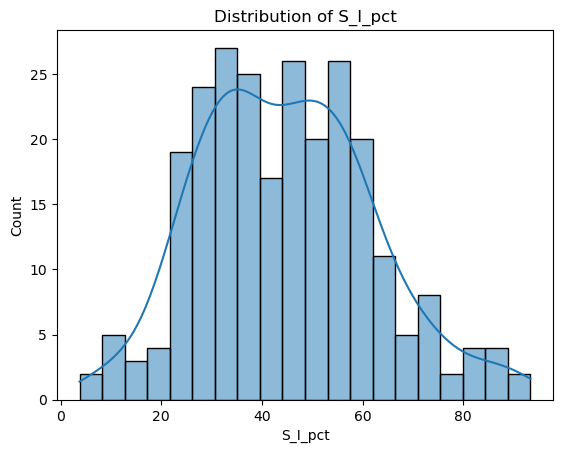

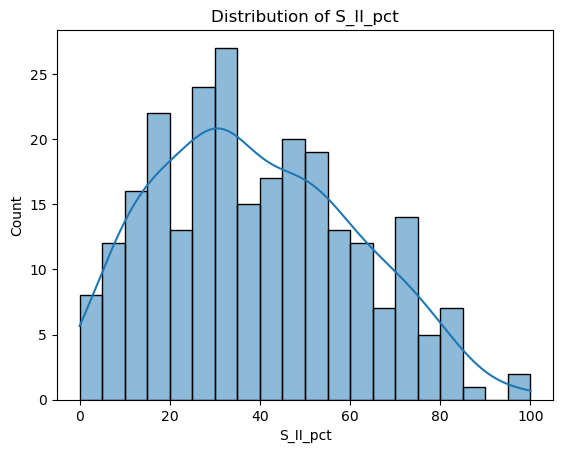

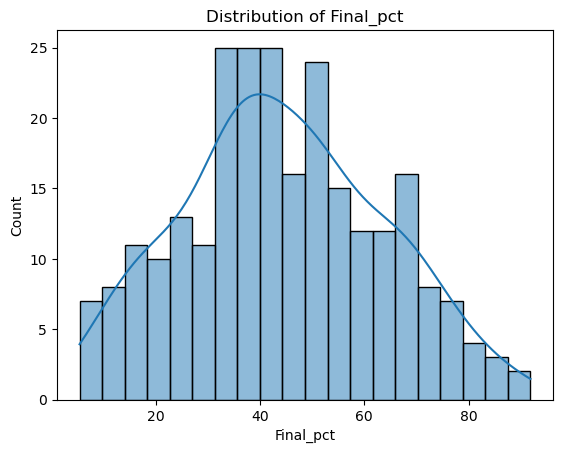

In [217]:
#performing EDA on mid1,mid2 and final

targets = ["S_I_pct", "S_II_pct", "Final_pct"]

for col in targets:
    plt.figure()
    sns.histplot(full_df[col], bins=20, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


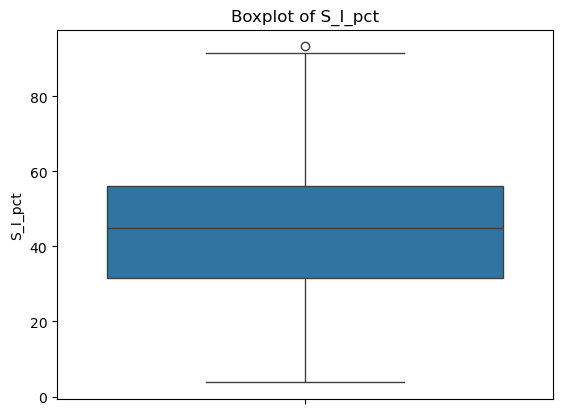

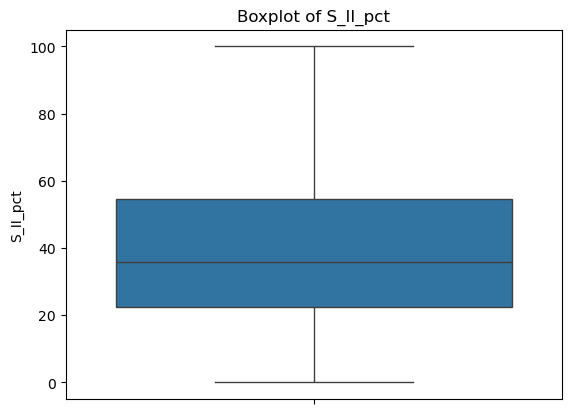

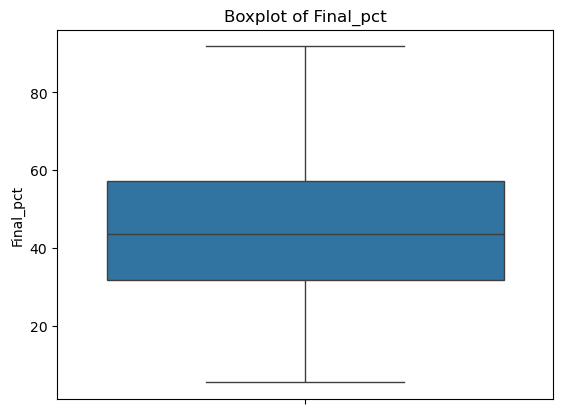

In [218]:
for col in targets:
    plt.figure()
    sns.boxplot(y=full_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


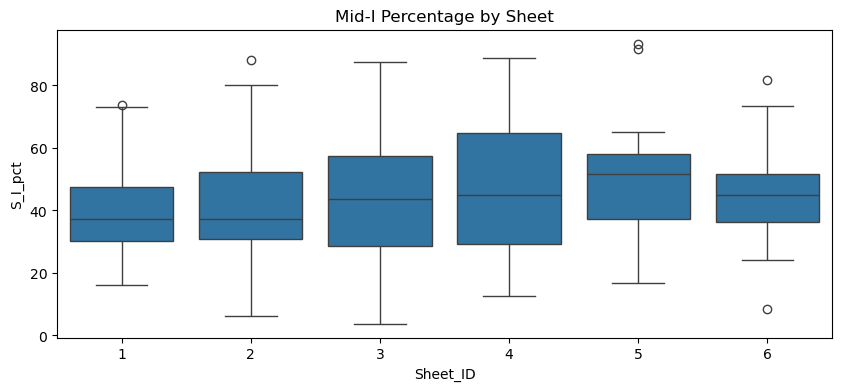

In [219]:
plt.figure(figsize=(10, 4))
sns.boxplot(x="Sheet_ID", y="S_I_pct", data=full_df)
plt.title("Mid-I Percentage by Sheet")
plt.show()

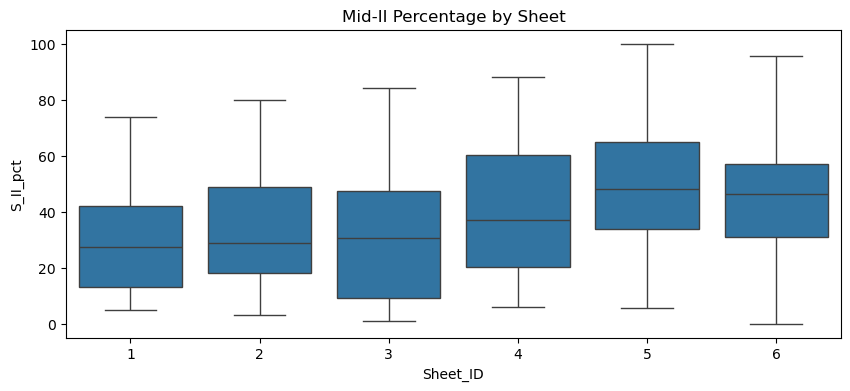

In [220]:
plt.figure(figsize=(10, 4))
sns.boxplot(x="Sheet_ID", y="S_II_pct", data=full_df)
plt.title("Mid-II Percentage by Sheet")
plt.show()

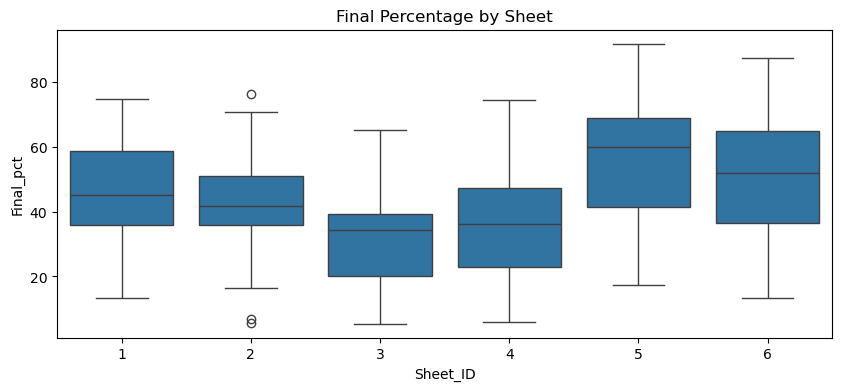

In [221]:
plt.figure(figsize=(10, 4))
sns.boxplot(x="Sheet_ID", y="Final_pct", data=full_df)
plt.title("Final Percentage by Sheet")
plt.show()

In [222]:
#Get all assignment & quiz columns
as_cols = [c for c in full_df.columns if c.startswith("As:")]
qz_cols = [c for c in full_df.columns if c.startswith("Qz:")]
all_cols = as_cols + qz_cols

#Build a dictionary of totals for each sheet
assignment_quiz_totals = {}
for meta in sheet_metadata:
    sheet_id = meta["Sheet_ID"]
    # Keep only assignments and quizzes totals
    totals_dict = {k: v for k, v in meta["Total"].items() if k.startswith("As:") or k.startswith("Qz:")}
    assignment_quiz_totals[sheet_id] = totals_dict

#Function to convert raw marks to percentage
def convert_to_pct(row, col):
    sheet_id = row["Sheet_ID"]
    total = assignment_quiz_totals.get(sheet_id, {}).get(col, np.nan)
    if pd.isna(row[col]) or pd.isna(total):
        return np.nan
    return (row[col] / total) * 100

#Apply the conversion
for col in all_cols:
    full_df[col + "_pct"] = full_df.apply(lambda row: convert_to_pct(row, col), axis=1)

#Verify
full_df[[c + "_pct" for c in all_cols]].describe()

,As:1_pct,As:2_pct,As:3_pct,As:4_pct,As:5_pct,As:6_pct,Qz:1_pct,Qz:2_pct,Qz:3_pct,Qz:4_pct,Qz:5_pct,Qz:6_pct,Qz:7_pct,Qz:8_pct
count,254.000000,254.000000,254.000000,254.000000,152.000000,62.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,152.000000,62.0
mean,58.578859,61.523876,66.911699,63.759907,66.584818,76.825687,47.262516,34.983721,42.866949,41.731034,39.516117,48.834184,48.962052,100.0
std,26.269287,30.117128,23.756724,29.573199,26.516873,16.663990,30.401414,28.341985,27.626106,32.260877,29.332101,27.804961,23.613084,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,41.062500,54.041667,55.666667,50.000000,57.500000,67.812500,20.000000,10.000000,20.000000,10.000000,15.000000,30.000000,33.333333,100.0
50%,62.500000,72.250000,72.958333,71.041667,71.250000,78.370370,50.000000,33.333333,43.750000,40.000000,37.500000,50.000000,46.239837,100.0
75%,80.769231,82.000000,84.166667,86.916667,87.500000,88.888889,70.000000,50.000000,60.000000,60.000000,64.125000,70.000000,63.541667,100.0
max,99.000000,100.000000,99.166667,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0


In [223]:
#defining the dataset for RQ:1 - Predict Mid 1
#selecting valid predictors that occur before Mid-I and setting Mid-I (%) as the target, while avoiding data leakage.

#target
y_rq1 = full_df["S_I_pct"]

#predictors
as_cols = [c for c in full_df.columns if c.startswith("As:") and "_pct" in c]
qz_cols = [c for c in full_df.columns if c.startswith("Qz:") and "_pct" in c]

X_rq1 = full_df[as_cols + qz_cols]

#training test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_rq1, y_rq1, test_size=0.2, random_state=42
)

#handling missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

In [224]:
# Dummy model
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

# Predictions
y_pred_dummy = dummy.predict(X_test)

# Evaluation
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)

mae_dummy, rmse_dummy, r2_dummy

(12.921777906564925, np.float64(16.3115081207057), -0.012585131311133146)

In [225]:
#applying simple regression
# Create a simple 1-feature predictor
X_train_simple = np.mean(X_train[:, :], axis=1).reshape(-1, 1)
X_test_simple  = np.mean(X_test[:, :], axis=1).reshape(-1, 1)

lin_reg_simple = LinearRegression()
lin_reg_simple.fit(X_train_simple, y_train)

y_pred_simple = lin_reg_simple.predict(X_test_simple)

mae_simple = mean_absolute_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

mae_simple, rmse_simple, r2_simple

(10.192719551254106, np.float64(12.758518348796922), 0.3804964523884443)

In [226]:
#multiple linear regression

# Train model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predictions
y_pred_lr = linreg.predict(X_test)

# Evaluation
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

mae_lr, rmse_lr, r2_lr


(9.919286117503972, np.float64(12.472283839286751), 0.40798149180264354)

In [227]:
coeff_df = pd.DataFrame({
    "Assessment": as_cols + qz_cols,
    "Coefficient": linreg.coef_
}).sort_values(by="Coefficient", ascending=False)

coeff_df

,Assessment,Coefficient
12,Qz:7_pct,0.155129
4,As:5_pct,0.132353
7,Qz:2_pct,0.132092
6,Qz:1_pct,0.113601
2,As:3_pct,0.083032
11,Qz:6_pct,0.082351
8,Qz:3_pct,0.079338
3,As:4_pct,0.053117
9,Qz:4_pct,0.044525
10,Qz:5_pct,0.025417


In [228]:
#comparison table

results_rq1 = pd.DataFrame({
    "Model": [
        "Dummy Regressor (Mean)",
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae_dummy,
        mae_simple,
        mae_lr
    ],
    "RMSE": [
        rmse_dummy,
        rmse_simple,
        rmse_lr
    ],
    "R2": [
        r2_dummy,
        r2_simple,
        r2_lr
    ]
})

results_rq1


,Model,MAE,RMSE,R2
0,Dummy Regressor (Mean),12.921778,16.311508,-0.012585
1,Simple Linear Regression,10.192720,12.758518,0.380496
2,Multiple Linear Regression,9.919286,12.472284,0.407981


In [229]:
# Number of bootstrap samples
lr = LinearRegression()
n_bootstrap = 500

mae_samples = []


for i in range(n_bootstrap):
    # Resample the training data with replacement
    X_resampled, y_resampled = resample(X_train, y_train, random_state=i)
    
    # Fit the model on the resampled data (example: multiple linear regression)
    lr.fit(X_resampled, y_resampled)
    
    # Predict on the resampled data
    y_pred = lr.predict(X_resampled)
    
    # Compute MAE and store it
    mae_samples.append(np.mean(np.abs(y_resampled - y_pred)))

# Convert to numpy array
mae_samples = np.array(mae_samples)

# 95% Confidence Interval
ci_lower = np.percentile(mae_samples, 2.5)
ci_upper = np.percentile(mae_samples, 97.5)

print("Bootstrapped MAE (95% CI):")
print(f"Lower bound: {ci_lower:.4f}")
print(f"Upper bound: {ci_upper:.4f}")
print(f"Mean MAE: {np.mean(mae_samples):.4f}")


Bootstrapped MAE (95% CI):
Lower bound: 9.6225
Upper bound: 11.7723
Mean MAE: 10.6877


In [230]:
# Predictions
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

# Compute metrics
MAE_train = mean_absolute_error(y_train, y_train_pred)
MAE_test  = mean_absolute_error(y_test, y_test_pred)

RMSE_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
RMSE_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

R2_train = r2_score(y_train, y_train_pred)
R2_test  = r2_score(y_test, y_test_pred)

# Print results
print(f"MAE_train  = {MAE_train:.3f}")
print(f"RMSE_train = {RMSE_train:.3f}")
print(f"R2_train   = {R2_train:.3f}")

print("-" * 30)

print(f"MAE_test   = {MAE_test:.3f}")
print(f"RMSE_test  = {RMSE_test:.3f}")
print(f"R2_test    = {R2_test:.3f}")


MAE_train  = 11.620
RMSE_train = 14.021
R2_train   = 0.347
------------------------------
MAE_test   = 11.018
RMSE_test  = 13.482
R2_test    = 0.308


In [231]:
#RQ-2 Predicting Mid 2

#target
y_rq2 = full_df["S_II_pct"]

#predictors
as_cols = [c for c in full_df.columns if c.startswith("As:") and "_pct" in c]
qz_cols = [c for c in full_df.columns if c.startswith("Qz:") and "_pct" in c]

X_rq2 = full_df[as_cols + qz_cols + ["S_I_pct"]]

#train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_rq2, y_rq2, test_size=0.2, random_state=42
)

#handling missing values 
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

In [232]:
#baseline model(dummy)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy = r2_score(y_test, y_pred_dummy)

mae_dummy_rq2  = mae_dummy
rmse_dummy_rq2 = rmse_dummy
r2_dummy_rq2   = r2_dummy

mae_dummy, rmse_dummy, r2_dummy

(17.393672859832424, np.float64(21.587660634622004), -0.011752626833660518)

In [233]:
#simple linear regression model
# Predictor (ONLY ONE VARIABLE)
X = full_df[["S_I_pct"]]     # Mid-I %
y = full_df["S_II_pct"]      # Mid-II %

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae_simple_rq2  = mae
rmse_simple_rq2 = rmse
r2_simple_rq2   = r2

mae, rmse, r2

(13.700249972191576, np.float64(16.369181925657855), 0.4182758052226474)

In [234]:
# RQ2: Multiple Linear Regression
# Target: Mid-II (%)
# Predictors: Mid-I (%), Assignments (%), Quizzes (%)

# Target
y_rq2 = full_df["S_II_pct"]

# Predictors
as_cols = [c for c in full_df.columns if c.startswith("As:") and "_pct" in c]
qz_cols = [c for c in full_df.columns if c.startswith("Qz:") and "_pct" in c]

X_rq2 = full_df[["S_I_pct"] + as_cols + qz_cols]

# Train-test split (80-20)

X_train, X_test, y_train, y_test = train_test_split(
    X_rq2, y_rq2, test_size=0.2, random_state=42
)

# Handle missing values (FIT on train only)

imputer = SimpleImputer(strategy="mean")
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

# Train Multiple Linear Regression

model_rq2_multi = LinearRegression()
model_rq2_multi.fit(X_train, y_train)

# Predictions
y_pred = model_rq2_multi.predict(X_test)

# Evaluation

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

mae_multi_rq2  = mae
rmse_multi_rq2 = rmse
r2_multi_rq2   = r2

(mae, rmse, r2)


(12.478076136693392, np.float64(15.472688401610382), 0.48024971597245647)

In [235]:
#comparison table

results_rq2 = pd.DataFrame({
    "Model": [
        "Dummy Regressor (Mean)",
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae_dummy_rq2,
        mae_simple_rq2,
        mae_multi_rq2
    ],
    "RMSE": [
        rmse_dummy_rq2,
        rmse_simple_rq2,
        rmse_multi_rq2
    ],
    "R2": [
        r2_dummy_rq2,
        r2_simple_rq2,
        r2_multi_rq2
    ]
})

results_rq2


,Model,MAE,RMSE,R2
0,Dummy Regressor (Mean),17.393673,21.587661,-0.011753
1,Simple Linear Regression,13.700250,16.369182,0.418276
2,Multiple Linear Regression,12.478076,15.472688,0.480250


In [236]:
#boostrapping

# number of bootstrap samples
n_bootstrap = 500
mae_scores = []

for i in range(n_bootstrap):
    # resample training data
    X_boot, y_boot = resample(
        X_train, y_train, replace=True, random_state=i
    )
    
    # train model
    model = LinearRegression()
    model.fit(X_boot, y_boot)
    
    # predict on original test set
    y_pred = model.predict(X_test)
    
    # store MAE
    mae_scores.append(mean_absolute_error(y_test, y_pred))

# convert to numpy array
mae_scores = np.array(mae_scores)

# 95% confidence interval
lower = np.percentile(mae_scores, 2.5)
upper = np.percentile(mae_scores, 97.5)
mean_mae = mae_scores.mean()

mean_mae, lower, upper

print("Bootstrapped MAE (95% CI):")
print(f"Lower bound: {lower:.4f}")
print(f"Upper bound: {upper:.4f}")
print(f"Mean MAE: {mean_mae:.4f}")

Bootstrapped MAE (95% CI):
Lower bound: 11.7692
Upper bound: 14.0537
Mean MAE: 12.9006


In [237]:
#Train vs Test error comparison (overfitting check)

# model (same one you used for RQ2)
lr = LinearRegression()
lr.fit(X_train, y_train)

# predictions
y_train_pred = lr.predict(X_train)
y_test_pred  = lr.predict(X_test)

# Train metrics
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

# Test metrics
mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

mae_train, mae_test, rmse_train, rmse_test, r2_train, r2_test

print(f"MAE_train  = {mae_train:.3f}")
print(f"RMSE_train = {rmse_train:.3f}")
print(f"R2_train   = {r2_train:.3f}")

print("-" * 30)

print(f"MAE_test   = {mae_test:.3f}")
print(f"RMSE_test  = {rmse_test:.3f}")
print(f"R2_test    = {r2_test:.3f}")


MAE_train  = 12.095
RMSE_train = 15.154
R2_train   = 0.517
------------------------------
MAE_test   = 12.478
RMSE_test  = 15.473
R2_test    = 0.480


In [238]:
# Columns for project
proj_cols = [c for c in full_df.columns if c.startswith("Proj:")]

# Function to convert raw marks to percentage using sheet totals
def convert_proj_to_pct(row, col):
    sheet_id = row["Sheet_ID"]
    total = combined_totals[sheet_id].get(col, np.nan)  # get the total for this project
    if pd.isna(row[col]) or pd.isna(total):
        return np.nan
    return (row[col] / total) * 100

# Apply for all project columns
for col in proj_cols:
    full_df[col + "_pct"] = full_df.apply(lambda row: convert_proj_to_pct(row, col), axis=1)


In [239]:
full_df

,Student_ID,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-II:1,Final:1,Sheet_ID,Proj:1,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5,S_I_raw,S_II_raw,Final_raw,S_I_pct,S_II_pct,Final_pct,As:1_pct,As:2_pct,As:3_pct,As:4_pct,As:5_pct,As:6_pct,Qz:1_pct,Qz:2_pct,Qz:3_pct,Qz:4_pct,Qz:5_pct,Qz:6_pct,Qz:7_pct,Qz:8_pct,Proj:1_pct
0,1,80.5,60.500000,73.500000,40.50000,59.00,70.5,3.5,5.0,2.0,8.0,3.393939,2.500000,9.0,2.0,17.5,6.25,35.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,6.25,35.75,43.750000,15.625000,35.750000,61.923077,86.428571,81.666667,81.000000,49.166667,78.333333,70.0,33.333333,20.00,80.0,33.939394,50.000000,75.000000,100.0,NaN
1,2,72.5,68.000000,39.000000,35.00000,80.50,71.0,2.5,7.0,0.0,10.0,7.000000,5.000000,10.0,2.0,12.5,11.00,53.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,11.00,53.50,31.250000,27.500000,53.500000,55.769231,97.142857,43.333333,70.000000,67.083333,78.888889,50.0,46.666667,0.00,100.0,70.000000,100.000000,83.333333,100.0,NaN
2,3,113.0,62.000000,0.000000,47.00000,80.00,80.0,3.5,2.5,1.0,1.0,2.000000,1.000000,12.0,2.0,9.5,6.50,32.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5,6.50,32.50,23.750000,16.250000,32.500000,86.923077,88.571429,0.000000,94.000000,66.666667,88.888889,70.0,16.666667,10.00,10.0,20.000000,20.000000,100.000000,100.0,NaN
3,4,61.0,43.500000,0.000000,22.00000,81.25,50.0,1.5,5.0,0.5,0.0,0.000000,1.000000,3.0,2.0,18.5,9.00,28.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.5,9.00,28.00,46.250000,22.500000,28.000000,46.923077,62.142857,0.000000,44.000000,67.708333,55.555556,30.0,33.333333,5.00,0.0,0.000000,20.000000,25.000000,100.0,NaN
4,5,104.0,67.000000,72.500000,45.00000,120.00,90.0,5.0,10.5,10.0,10.0,6.500000,5.000000,9.0,2.0,28.5,17.50,74.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.5,17.50,74.75,71.250000,43.750000,74.750000,80.000000,95.714286,80.555556,90.000000,100.000000,100.000000,100.0,70.000000,100.00,100.0,65.000000,100.000000,75.000000,100.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,0.0,67.479167,64.061224,49.93617,NaN,NaN,5.0,0.0,1.5,0.0,1.722222,3.336957,NaN,NaN,16.0,7.00,15.50,6,NaN,0.5,13.0,0.0,3.0,9.0,0.0,1.0,0.0,29.5,10.00,25.50,49.166667,18.181818,23.181818,0.000000,56.232639,64.061224,62.420213,NaN,NaN,50.0,0.000000,18.75,0.0,17.222222,33.369565,NaN,NaN,NaN
250,48,70.5,92.000000,73.000000,61.00000,NaN,NaN,1.5,7.0,3.0,0.0,1.000000,4.000000,NaN,NaN,18.0,17.00,35.00,6,NaN,2.0,13.0,2.0,7.0,7.0,14.0,5.0,8.0,33.0,26.00,69.00,55.000000,47.272727,62.727273,70.500000,76.666667,73.000000,76.250000,NaN,NaN,15.0,70.000000,37.50,0.0,10.000000,40.000000,NaN,NaN,NaN
251,49,41.5,0.000000,88.000000,72.00000,NaN,NaN,6.0,2.0,3.0,0.0,0.000000,3.000000,NaN,NaN,19.5,12.00,36.00,6,NaN,2.0,13.0,3.0,5.5,5.0,9.5,4.5,1.5,34.5,20.50,56.50,57.500000,37.272727,51.363636,41.500000,0.000000,88.000000,90.000000,NaN,NaN,60.0,20.000000,37.50,0.0,0.000000,30.000000,NaN,NaN,NaN
252,50,32.0,96.000000,77.000000,66.00000,NaN,NaN,0.0,0.0,3.5,6.0,2.500000,3.336957,NaN,NaN,17.0,13.00,33.00,6,NaN,0.5,11.0,1.0,16.0,6.0,13.5,2.0,4.5,28.5,30.00,59.00,47.500000,54.545455,53.636364,32.000000,80.000000,77.000000,82.500000,NaN,NaN,0.0,0.000000,43.75,60.0,25.000000,33.369565,NaN,NaN,NaN


In [240]:
#RQ3 (final exam marks prediction)
# Target
y_rq3 = full_df["Final_pct"]

# Predictors
as_cols = [c for c in full_df.columns if c.startswith("As:") and "_pct" in c]
qz_cols = [c for c in full_df.columns if c.startswith("Qz:") and "_pct" in c]

mid_cols = ["S_I_pct", "S_II_pct"]

X_rq3 = full_df[as_cols + qz_cols + mid_cols]

In [241]:
#Defining predictor and targets
# Target
y_rq3 = full_df["Final_pct"]

# Predictors: assignments, quizzes, Mid-I and Mid-II
as_cols = [c for c in full_df.columns if c.startswith("As:") and "_pct" in c]
qz_cols = [c for c in full_df.columns if c.startswith("Qz:") and "_pct" in c]
mid_cols = ["S_I_pct", "S_II_pct"]

X_rq3 = full_df[as_cols + qz_cols + mid_cols]

#train test split
X_train_rq3, X_test_rq3, y_train_rq3, y_test_rq3 = train_test_split(
    X_rq3, y_rq3, test_size=0.2, random_state=42
)

# Save column names before imputation
X_train_cols = X_rq3.columns.tolist()

#handle missing values
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")
X_train_rq3 = imputer.fit_transform(X_train_rq3)
X_test_rq3 = imputer.transform(X_test_rq3)

In [242]:
# Dummy model (predicts mean of training targets)
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

# Predictions
y_pred_dummy = dummy.predict(X_test)

# Evaluation
mae_dummy_rq3 = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy_rq3 = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
r2_dummy_rq3 = r2_score(y_test, y_pred_dummy)

print("Dummy Regressor (Mean) Results for RQ3:")
print("MAE:", mae_dummy_rq3)
print("RMSE:", rmse_dummy_rq3)
print("R2:", r2_dummy_rq3)

Dummy Regressor (Mean) Results for RQ3:
MAE: 17.393672859832424
RMSE: 21.587660634622004
R2: -0.011752626833660518


In [243]:

#Select Mid-II as single predictor for simple regression

s_ii_idx = X_train_cols.index("S_II_pct")

X_rq3_simple = X_train_rq3[:, s_ii_idx].reshape(-1, 1)
X_test_simple = X_test_rq3[:, s_ii_idx].reshape(-1, 1)

# Fit simple linear regression

lr_simple_rq3 = LinearRegression()
lr_simple_rq3.fit(X_rq3_simple, y_train_rq3)

# Predictions
y_pred_simple_rq3 = lr_simple_rq3.predict(X_test_simple)

# Evaluation
mae_simple_rq3 = mean_absolute_error(y_test_rq3, y_pred_simple_rq3)
rmse_simple_rq3 = np.sqrt(mean_squared_error(y_test_rq3, y_pred_simple_rq3))
r2_simple_rq3 = r2_score(y_test_rq3, y_pred_simple_rq3)

print("Simple Linear Regression RQ3")
print("MAE:", mae_simple_rq3)
print("RMSE:", rmse_simple_rq3)
print("R2:", r2_simple_rq3)

Simple Linear Regression RQ3
MAE: 9.535646385405197
RMSE: 11.652434970924284
R2: 0.6461810352915969


In [244]:
# Multiple Linear Regression

X_rq3_multi = X_train_rq3
X_test_rq3_multi = X_test_rq3

# Fit the model
lr_multi_rq3 = LinearRegression()
lr_multi_rq3.fit(X_rq3_multi, y_train_rq3)

# Predictions
y_pred_multi_rq3 = lr_multi_rq3.predict(X_test_rq3_multi)

# Evaluation
mae_multi_rq3 = mean_absolute_error(y_test_rq3, y_pred_multi_rq3)
rmse_multi_rq3 = np.sqrt(mean_squared_error(y_test_rq3, y_pred_multi_rq3))
r2_multi_rq3 = r2_score(y_test_rq3, y_pred_multi_rq3)

print("Multiple Linear Regression RQ3")
print("MAE:", mae_multi_rq3)
print("RMSE:", rmse_multi_rq3)
print("R2:", r2_multi_rq3)


Multiple Linear Regression RQ3
MAE: 9.487900707496184
RMSE: 11.519540018030538
R2: 0.654205559104148


In [245]:
# Coefficient table for RQ3 multiple regression
coef_rq3 = pd.DataFrame({
    "Assessment": X_train_cols,
    "Coefficient": lr_multi_rq3.coef_
}).sort_values(by="Coefficient", ascending=False)

coef_rq3


,Assessment,Coefficient
15,S_II_pct,5.183616e-01
14,S_I_pct,1.567941e-01
3,As:4_pct,1.343528e-01
11,Qz:6_pct,7.570213e-02
2,As:3_pct,5.346390e-02
12,Qz:7_pct,4.584103e-02
6,Qz:1_pct,3.473767e-02
5,As:6_pct,1.929101e-02
1,As:2_pct,6.913494e-03
13,Qz:8_pct,-2.775558e-17


In [246]:
import pandas as pd

# Comparison table for RQ3
results_rq3 = pd.DataFrame({
    "Model": [
        "Dummy Regressor (Mean)",
        "Simple Linear Regression",
        "Multiple Linear Regression"
    ],
    "MAE": [
        mae_dummy_rq3,
        mae_simple_rq3,
        mae_multi_rq3
    ],
    "RMSE": [
        rmse_dummy_rq3,
        rmse_simple_rq3,
        rmse_multi_rq3
    ],
    "R2": [
        r2_dummy_rq3,
        r2_simple_rq3,
        r2_multi_rq3
    ]
})

results_rq3


,Model,MAE,RMSE,R2
0,Dummy Regressor (Mean),17.393673,21.587661,-0.011753
1,Simple Linear Regression,9.535646,11.652435,0.646181
2,Multiple Linear Regression,9.487901,11.519540,0.654206


In [247]:
# Number of bootstrap samples
n_bootstrap = 500
mae_samples = []

for i in range(n_bootstrap):
    # Resample training data with replacement
    X_resampled, y_resampled = resample(X_train_rq3, y_train_rq3, random_state=i)
    
    # Fit the model on resampled data
    lr_multi_rq3.fit(X_resampled, y_resampled)
    
    # Predict on the same resampled data
    y_pred = lr_multi_rq3.predict(X_resampled)
    
    # Compute MAE and store
    mae_samples.append(mean_absolute_error(y_resampled, y_pred))

# Compute 95% confidence interval
ci_lower = np.percentile(mae_samples, 2.5)
ci_upper = np.percentile(mae_samples, 97.5)
mae_mean = np.mean(mae_samples)

print("Bootstrapped MAE (95% CI):")
print(f"Lower bound: {ci_lower:.4f}")
print(f"Upper bound: {ci_upper:.4f}")
print(f"Mean MAE: {mae_mean:.4f}")

Bootstrapped MAE (95% CI):
Lower bound: 7.3823
Upper bound: 9.1756
Mean MAE: 8.2710


In [248]:
#train vs test errors

# Predictions
y_train_pred = lr_multi_rq3.predict(X_train_rq3)
y_test_pred = lr_multi_rq3.predict(X_test_rq3)

# Train metrics
MAE_train = mean_absolute_error(y_train_rq3, y_train_pred)
RMSE_train = np.sqrt(mean_squared_error(y_train_rq3, y_train_pred))
R2_train = r2_score(y_train_rq3, y_train_pred)

# Test metrics
MAE_test = mean_absolute_error(y_test_rq3, y_test_pred)
RMSE_test = np.sqrt(mean_squared_error(y_test_rq3, y_test_pred))
R2_test = r2_score(y_test_rq3, y_test_pred)

print("Train MAE:", MAE_train)
print("Train RMSE:", RMSE_train)
print("Train R2:", R2_train)
print("Test MAE:", MAE_test)
print("Test RMSE:", RMSE_test)
print("Test R2:", R2_test)

Train MAE: 8.760282753321208
Train RMSE: 11.056771124496304
Train R2: 0.6585448676412479
Test MAE: 9.380072999277875
Test RMSE: 11.376872868860115
Test R2: 0.6627177070376178


In [249]:
!pip install gradio

In [250]:
full_df.columns

Index(['Student_ID', 'As:1', 'As:2', 'As:3', 'As:4', 'As:5', 'As:6', 'Qz:1',
       'Qz:2', 'Qz:3', 'Qz:4', 'Qz:5', 'Qz:6', 'Qz:7', 'Qz:8', 'S-I:1',
       'S-II:1', 'Final:1', 'Sheet_ID', 'Proj:1', 'S-I:2', 'S-I:3', 'S-II:2',
       'S-II:3', 'Final:2', 'Final:3', 'Final:4', 'Final:5', 'S_I_raw',
       'S_II_raw', 'Final_raw', 'S_I_pct', 'S_II_pct', 'Final_pct', 'As:1_pct',
       'As:2_pct', 'As:3_pct', 'As:4_pct', 'As:5_pct', 'As:6_pct', 'Qz:1_pct',
       'Qz:2_pct', 'Qz:3_pct', 'Qz:4_pct', 'Qz:5_pct', 'Qz:6_pct', 'Qz:7_pct',
       'Qz:8_pct', 'Proj:1_pct'],
      dtype='object')

In [251]:
pd.set_option('display.max_columns', None)
full_df

,Student_ID,As:1,As:2,As:3,As:4,As:5,As:6,Qz:1,Qz:2,Qz:3,Qz:4,Qz:5,Qz:6,Qz:7,Qz:8,S-I:1,S-II:1,Final:1,Sheet_ID,Proj:1,S-I:2,S-I:3,S-II:2,S-II:3,Final:2,Final:3,Final:4,Final:5,S_I_raw,S_II_raw,Final_raw,S_I_pct,S_II_pct,Final_pct,As:1_pct,As:2_pct,As:3_pct,As:4_pct,As:5_pct,As:6_pct,Qz:1_pct,Qz:2_pct,Qz:3_pct,Qz:4_pct,Qz:5_pct,Qz:6_pct,Qz:7_pct,Qz:8_pct,Proj:1_pct
0,1,80.5,60.500000,73.500000,40.50000,59.00,70.5,3.5,5.0,2.0,8.0,3.393939,2.500000,9.0,2.0,17.5,6.25,35.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.5,6.25,35.75,43.750000,15.625000,35.750000,61.923077,86.428571,81.666667,81.000000,49.166667,78.333333,70.0,33.333333,20.00,80.0,33.939394,50.000000,75.000000,100.0,NaN
1,2,72.5,68.000000,39.000000,35.00000,80.50,71.0,2.5,7.0,0.0,10.0,7.000000,5.000000,10.0,2.0,12.5,11.00,53.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.5,11.00,53.50,31.250000,27.500000,53.500000,55.769231,97.142857,43.333333,70.000000,67.083333,78.888889,50.0,46.666667,0.00,100.0,70.000000,100.000000,83.333333,100.0,NaN
2,3,113.0,62.000000,0.000000,47.00000,80.00,80.0,3.5,2.5,1.0,1.0,2.000000,1.000000,12.0,2.0,9.5,6.50,32.50,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.5,6.50,32.50,23.750000,16.250000,32.500000,86.923077,88.571429,0.000000,94.000000,66.666667,88.888889,70.0,16.666667,10.00,10.0,20.000000,20.000000,100.000000,100.0,NaN
3,4,61.0,43.500000,0.000000,22.00000,81.25,50.0,1.5,5.0,0.5,0.0,0.000000,1.000000,3.0,2.0,18.5,9.00,28.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.5,9.00,28.00,46.250000,22.500000,28.000000,46.923077,62.142857,0.000000,44.000000,67.708333,55.555556,30.0,33.333333,5.00,0.0,0.000000,20.000000,25.000000,100.0,NaN
4,5,104.0,67.000000,72.500000,45.00000,120.00,90.0,5.0,10.5,10.0,10.0,6.500000,5.000000,9.0,2.0,28.5,17.50,74.75,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.5,17.50,74.75,71.250000,43.750000,74.750000,80.000000,95.714286,80.555556,90.000000,100.000000,100.000000,100.0,70.000000,100.00,100.0,65.000000,100.000000,75.000000,100.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,0.0,67.479167,64.061224,49.93617,NaN,NaN,5.0,0.0,1.5,0.0,1.722222,3.336957,NaN,NaN,16.0,7.00,15.50,6,NaN,0.5,13.0,0.0,3.0,9.0,0.0,1.0,0.0,29.5,10.00,25.50,49.166667,18.181818,23.181818,0.000000,56.232639,64.061224,62.420213,NaN,NaN,50.0,0.000000,18.75,0.0,17.222222,33.369565,NaN,NaN,NaN
250,48,70.5,92.000000,73.000000,61.00000,NaN,NaN,1.5,7.0,3.0,0.0,1.000000,4.000000,NaN,NaN,18.0,17.00,35.00,6,NaN,2.0,13.0,2.0,7.0,7.0,14.0,5.0,8.0,33.0,26.00,69.00,55.000000,47.272727,62.727273,70.500000,76.666667,73.000000,76.250000,NaN,NaN,15.0,70.000000,37.50,0.0,10.000000,40.000000,NaN,NaN,NaN
251,49,41.5,0.000000,88.000000,72.00000,NaN,NaN,6.0,2.0,3.0,0.0,0.000000,3.000000,NaN,NaN,19.5,12.00,36.00,6,NaN,2.0,13.0,3.0,5.5,5.0,9.5,4.5,1.5,34.5,20.50,56.50,57.500000,37.272727,51.363636,41.500000,0.000000,88.000000,90.000000,NaN,NaN,60.0,20.000000,37.50,0.0,0.000000,30.000000,NaN,NaN,NaN
252,50,32.0,96.000000,77.000000,66.00000,NaN,NaN,0.0,0.0,3.5,6.0,2.500000,3.336957,NaN,NaN,17.0,13.00,33.00,6,NaN,0.5,11.0,1.0,16.0,6.0,13.5,2.0,4.5,28.5,30.00,59.00,47.500000,54.545455,53.636364,32.000000,80.000000,77.000000,82.500000,NaN,NaN,0.0,0.000000,43.75,60.0,25.000000,33.369565,NaN,NaN,NaN


In [252]:
# Keep only the percentage columns and Student_ID
pct_columns = ['Student_ID'] + [col for col in full_df.columns if col.endswith('_pct')]
full_df_pct = full_df[pct_columns]

# Save the preprocessed data with only percentage columns
full_df_pct.to_excel(r"D:\Data Science\Assignment 4\preprocessed_dataset.xlsx", index=False)

In [253]:
full_df_pct

,Student_ID,S_I_pct,S_II_pct,Final_pct,As:1_pct,As:2_pct,As:3_pct,As:4_pct,As:5_pct,As:6_pct,Qz:1_pct,Qz:2_pct,Qz:3_pct,Qz:4_pct,Qz:5_pct,Qz:6_pct,Qz:7_pct,Qz:8_pct,Proj:1_pct
0,1,43.750000,15.625000,35.750000,61.923077,86.428571,81.666667,81.000000,49.166667,78.333333,70.0,33.333333,20.00,80.0,33.939394,50.000000,75.000000,100.0,NaN
1,2,31.250000,27.500000,53.500000,55.769231,97.142857,43.333333,70.000000,67.083333,78.888889,50.0,46.666667,0.00,100.0,70.000000,100.000000,83.333333,100.0,NaN
2,3,23.750000,16.250000,32.500000,86.923077,88.571429,0.000000,94.000000,66.666667,88.888889,70.0,16.666667,10.00,10.0,20.000000,20.000000,100.000000,100.0,NaN
3,4,46.250000,22.500000,28.000000,46.923077,62.142857,0.000000,44.000000,67.708333,55.555556,30.0,33.333333,5.00,0.0,0.000000,20.000000,25.000000,100.0,NaN
4,5,71.250000,43.750000,74.750000,80.000000,95.714286,80.555556,90.000000,100.000000,100.000000,100.0,70.000000,100.00,100.0,65.000000,100.000000,75.000000,100.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249,47,49.166667,18.181818,23.181818,0.000000,56.232639,64.061224,62.420213,NaN,NaN,50.0,0.000000,18.75,0.0,17.222222,33.369565,NaN,NaN,NaN
250,48,55.000000,47.272727,62.727273,70.500000,76.666667,73.000000,76.250000,NaN,NaN,15.0,70.000000,37.50,0.0,10.000000,40.000000,NaN,NaN,NaN
251,49,57.500000,37.272727,51.363636,41.500000,0.000000,88.000000,90.000000,NaN,NaN,60.0,20.000000,37.50,0.0,0.000000,30.000000,NaN,NaN,NaN
252,50,47.500000,54.545455,53.636364,32.000000,80.000000,77.000000,82.500000,NaN,NaN,0.0,0.000000,43.75,60.0,25.000000,33.369565,NaN,NaN,NaN


* Running on local URL:  http://127.0.0.1:7868
* Running on public URL: https://1afb4a1e176d21ca6f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


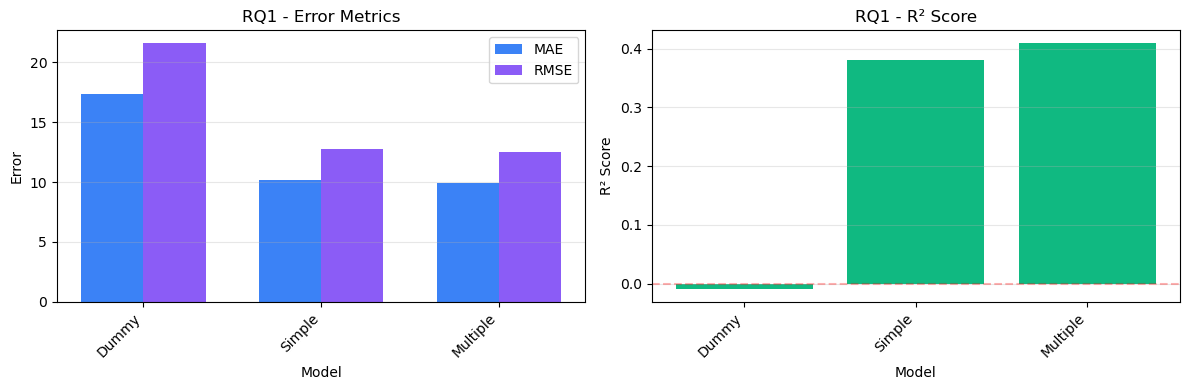

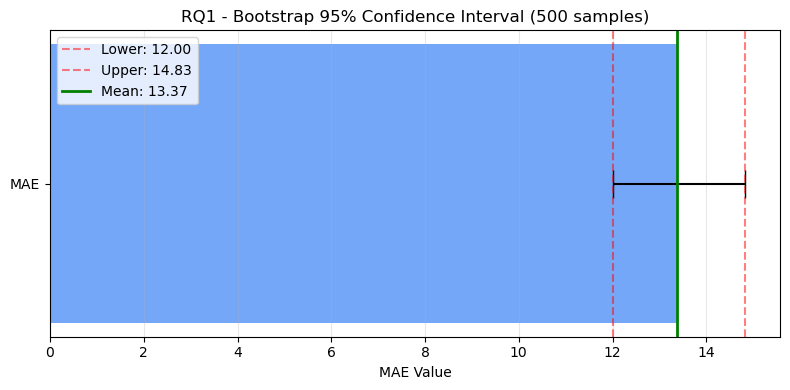

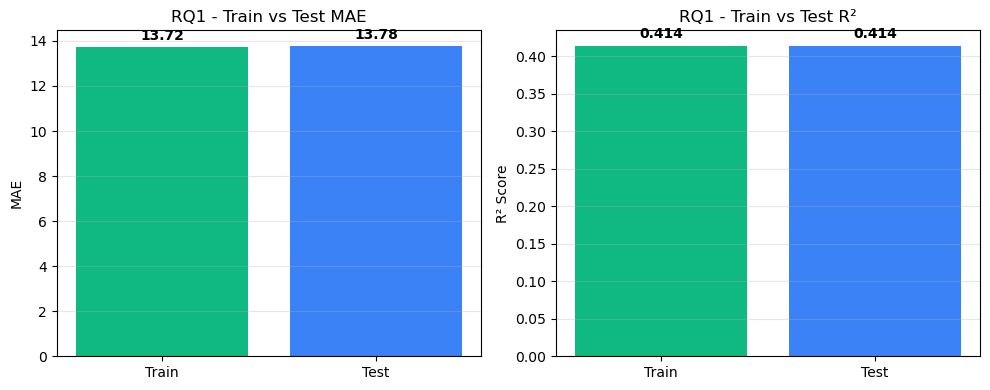

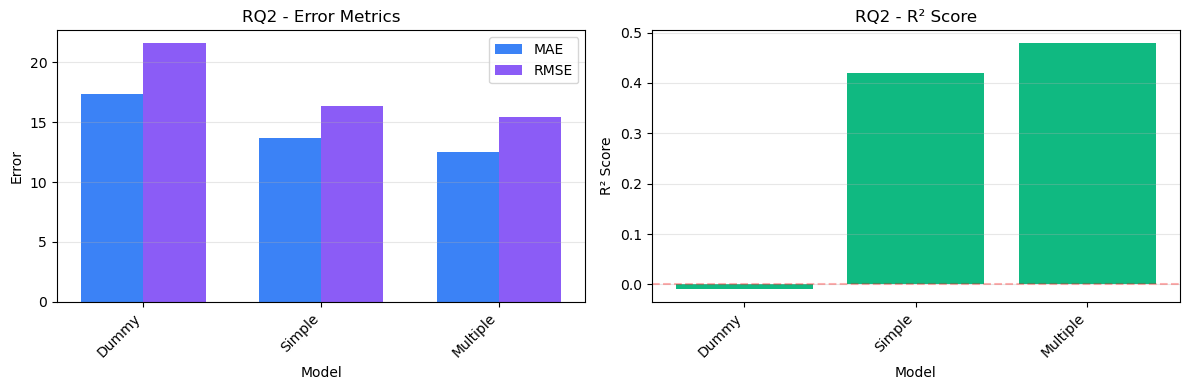

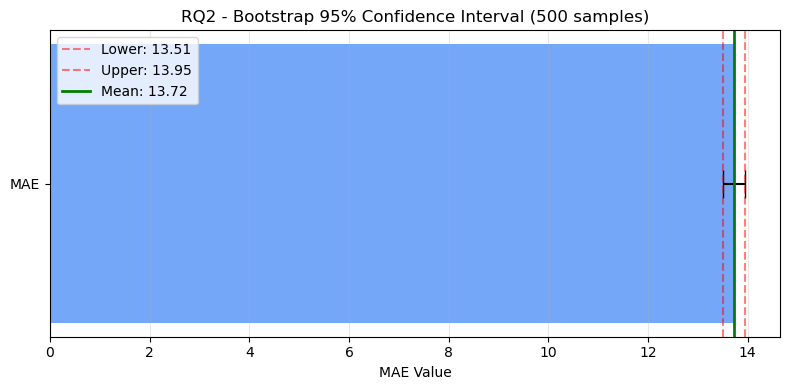

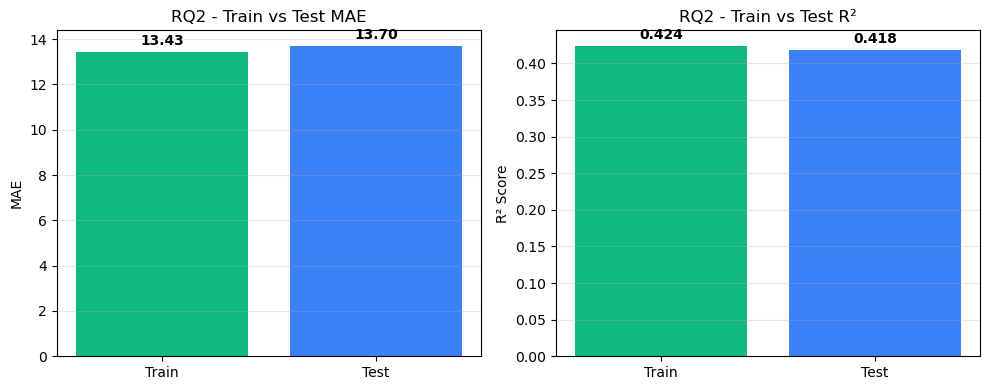

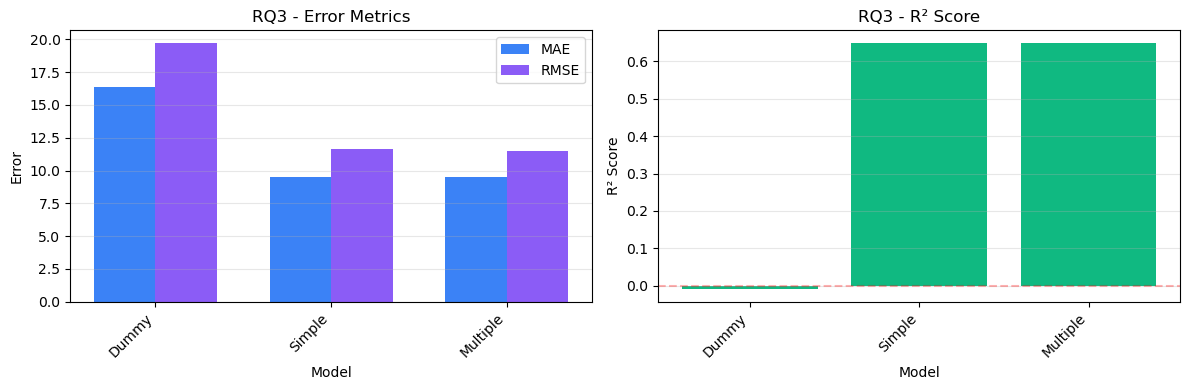

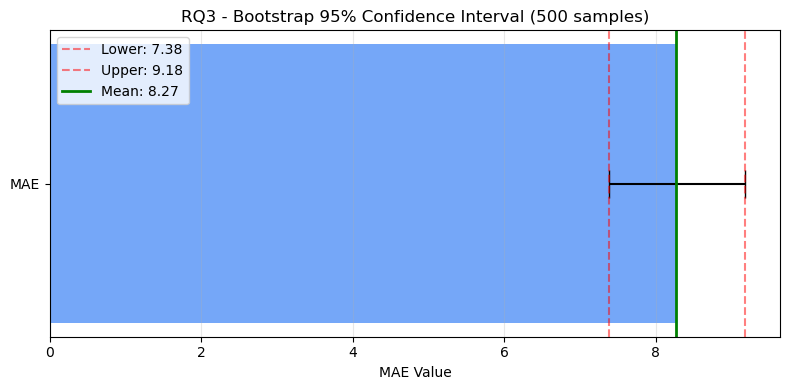

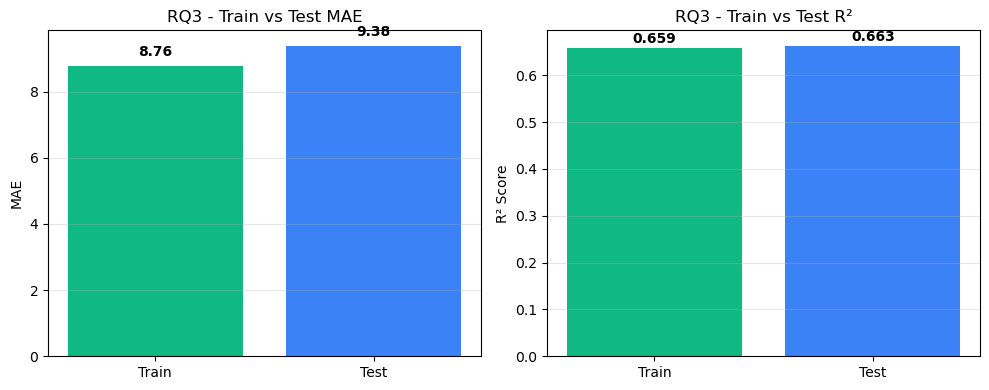

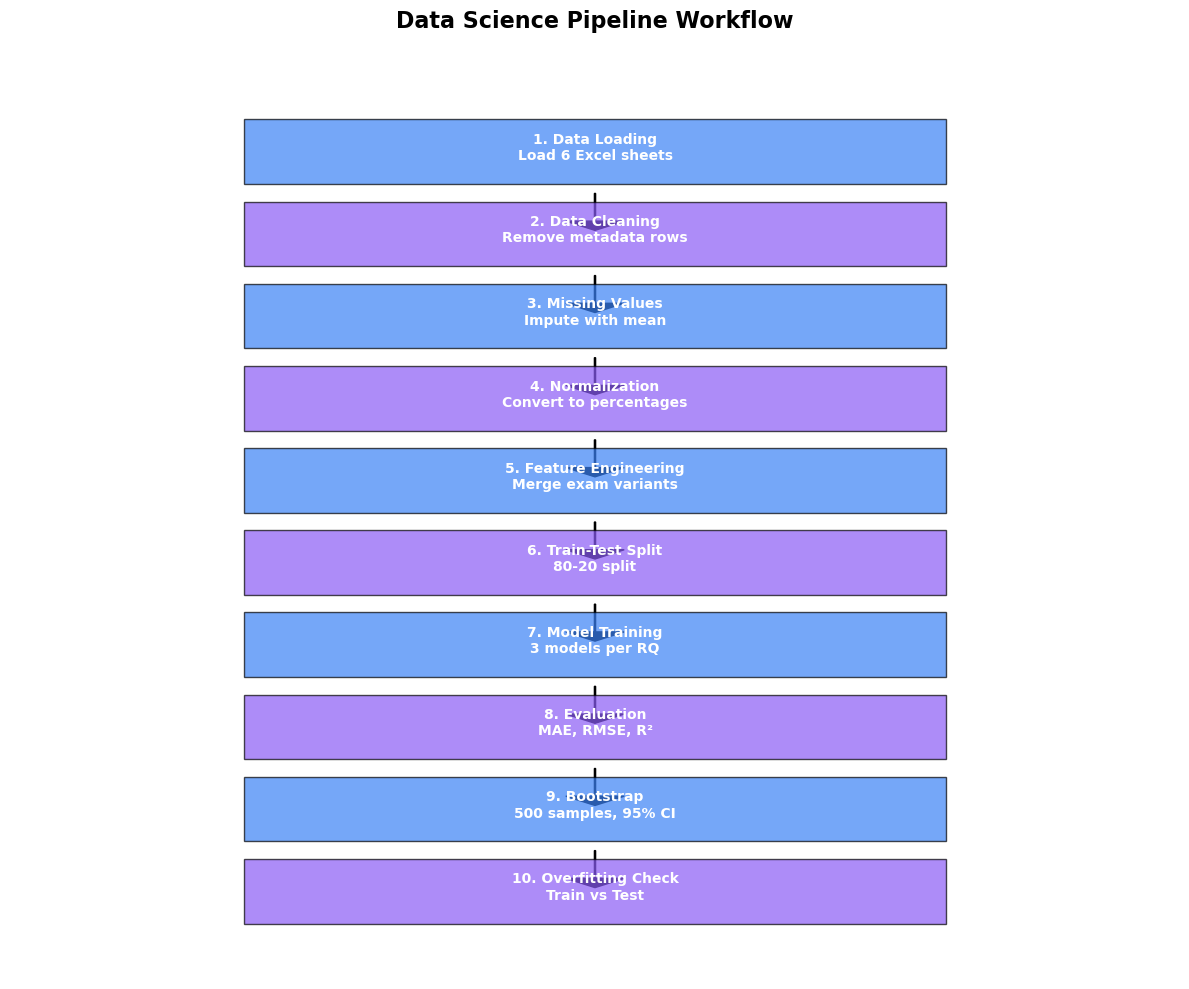

In [255]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results Data
rq1_results = pd.DataFrame({
    "Model": ["Dummy Regressor (Mean)", "Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [17.39, 10.19, 9.92],
    "RMSE": [21.59, 12.76, 12.47],
    "R²": [-0.01, 0.38, 0.41]
})

rq2_results = pd.DataFrame({
    "Model": ["Dummy Regressor (Mean)", "Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [17.39, 13.70, 12.48],
    "RMSE": [21.59, 16.37, 15.47],
    "R²": [-0.01, 0.42, 0.48]
})

rq3_results = pd.DataFrame({
    "Model": ["Dummy Regressor (Mean)", "Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [16.33, 9.54, 9.49],
    "RMSE": [19.70, 11.65, 11.52],
    "R²": [-0.01, 0.65, 0.65]
})

bootstrap_results = {
    "RQ1": {"Lower (2.5%)": 12.00, "Mean": 13.37, "Upper (97.5%)": 14.83},
    "RQ2": {"Lower (2.5%)": 13.51, "Mean": 13.72, "Upper (97.5%)": 13.95},
    "RQ3": {"Lower (2.5%)": 7.38, "Mean": 8.27, "Upper (97.5%)": 9.18}
}

overfitting_results = {
    "RQ1": {"Train MAE": 13.72, "Test MAE": 13.78, "Train R²": 0.414, "Test R²": 0.414},
    "RQ2": {"Train MAE": 13.43, "Test MAE": 13.70, "Train R²": 0.424, "Test R²": 0.418},
    "RQ3": {"Train MAE": 8.76, "Test MAE": 9.38, "Train R²": 0.659, "Test R²": 0.663}
}

def create_comparison_plot(results_df, title):
    """Create bar plot comparing models"""
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
    # MAE and RMSE comparison
    x = np.arange(len(results_df))
    width = 0.35
    
    ax[0].bar(x - width/2, results_df['MAE'], width, label='MAE', color='#3B82F6')
    ax[0].bar(x + width/2, results_df['RMSE'], width, label='RMSE', color='#8B5CF6')
    ax[0].set_xlabel('Model')
    ax[0].set_ylabel('Error')
    ax[0].set_title(f'{title} - Error Metrics')
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(['Dummy', 'Simple', 'Multiple'], rotation=45, ha='right')
    ax[0].legend()
    ax[0].grid(axis='y', alpha=0.3)
    
    # R² comparison
    x_pos = np.arange(len(results_df))
    ax[1].bar(x_pos, results_df['R²'], color='#10B981')
    ax[1].set_xlabel('Model')
    ax[1].set_ylabel('R² Score')
    ax[1].set_title(f'{title} - R² Score')
    ax[1].set_xticks(x_pos)
    ax[1].set_xticklabels(['Dummy', 'Simple', 'Multiple'], rotation=45, ha='right')
    ax[1].axhline(y=0, color='r', linestyle='--', alpha=0.3)
    ax[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    return fig

def create_bootstrap_plot(rq):
    """Create bootstrap confidence interval plot"""
    data = bootstrap_results[rq]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    
    ax.barh(['MAE'], [data['Mean']], xerr=[[data['Mean'] - data['Lower (2.5%)']], 
                                            [data['Upper (97.5%)'] - data['Mean']]], 
            color='#3B82F6', alpha=0.7, capsize=10)
    
    ax.set_xlabel('MAE Value')
    ax.set_title(f'{rq} - Bootstrap 95% Confidence Interval (500 samples)')
    ax.axvline(data['Lower (2.5%)'], color='red', linestyle='--', alpha=0.5, label=f"Lower: {data['Lower (2.5%)']:.2f}")
    ax.axvline(data['Upper (97.5%)'], color='red', linestyle='--', alpha=0.5, label=f"Upper: {data['Upper (97.5%)']:.2f}")
    ax.axvline(data['Mean'], color='green', linestyle='-', linewidth=2, label=f"Mean: {data['Mean']:.2f}")
    ax.legend()
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    return fig

def create_overfitting_plot(rq):
    """Create train vs test comparison plot"""
    data = overfitting_results[rq]
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    # MAE comparison
    metrics = ['Train', 'Test']
    mae_values = [data['Train MAE'], data['Test MAE']]
    
    ax[0].bar(metrics, mae_values, color=['#10B981', '#3B82F6'])
    ax[0].set_ylabel('MAE')
    ax[0].set_title(f'{rq} - Train vs Test MAE')
    ax[0].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(mae_values):
        ax[0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')
    
    # R² comparison
    r2_values = [data['Train R²'], data['Test R²']]
    
    ax[1].bar(metrics, r2_values, color=['#10B981', '#3B82F6'])
    ax[1].set_ylabel('R² Score')
    ax[1].set_title(f'{rq} - Train vs Test R²')
    ax[1].grid(axis='y', alpha=0.3)
    
    for i, v in enumerate(r2_values):
        ax[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    return fig

def get_rq_analysis(rq_num):
    """Get complete analysis for a research question"""
    if rq_num == 1:
        results = rq1_results
        rq_key = "RQ1"
        description = "**RQ1: Predicting Midterm I Marks**\n\nUsing only assignments and quizzes completed before Mid-I exam."
    elif rq_num == 2:
        results = rq2_results
        rq_key = "RQ2"
        description = "**RQ2: Predicting Midterm II Marks**\n\nUsing Mid-I results, assignments, and quizzes completed before Mid-II."
    else:
        results = rq3_results
        rq_key = "RQ3"
        description = "**RQ3: Predicting Final Exam Marks**\n\nUsing all previous assessments including both midterms, assignments, and quizzes."
    
    comparison_plot = create_comparison_plot(results, rq_key)
    bootstrap_plot = create_bootstrap_plot(rq_key)
    overfitting_plot = create_overfitting_plot(rq_key)
    
    return description, results, comparison_plot, bootstrap_plot, overfitting_plot

def get_workflow_diagram():
    """Create workflow diagram"""
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.axis('off')
    
    steps = [
        "1. Data Loading\nLoad 6 Excel sheets",
        "2. Data Cleaning\nRemove metadata rows",
        "3. Missing Values\nImpute with mean",
        "4. Normalization\nConvert to percentages",
        "5. Feature Engineering\nMerge exam variants",
        "6. Train-Test Split\n80-20 split",
        "7. Model Training\n3 models per RQ",
        "8. Evaluation\nMAE, RMSE, R²",
        "9. Bootstrap\n500 samples, 95% CI",
        "10. Overfitting Check\nTrain vs Test"
    ]
    
    y_positions = np.linspace(0.9, 0.1, len(steps))
    
    for i, (step, y) in enumerate(zip(steps, y_positions)):
        # Draw box
        box = plt.Rectangle((0.2, y-0.04), 0.6, 0.07, 
                            facecolor='#3B82F6' if i % 2 == 0 else '#8B5CF6',
                            edgecolor='black', alpha=0.7)
        ax.add_patch(box)
        
        # Add text
        ax.text(0.5, y, step, ha='center', va='center', 
               fontsize=10, color='white', fontweight='bold')
        
        # Draw arrow
        if i < len(steps) - 1:
            ax.arrow(0.5, y-0.05, 0, -0.03, head_width=0.05, 
                    head_length=0.01, fc='black', ec='black')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title('Data Science Pipeline Workflow', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    return fig

# Create Gradio Interface
demo = gr.Blocks(title="Student Marks Prediction Dashboard")

with demo:
    
    gr.Markdown("""
    # 📊 Student Performance Prediction Dashboard
    ### Predicting Mid-I, Mid-II, and Final Exam Marks using Machine Learning
    
    **Course:** CS 4048 - Data Science | **Institution:** National University of Computer & Emerging Sciences
    """)
    
    with gr.Tabs():
        # Overview Tab
        with gr.Tab("📋 Overview"):
            gr.Markdown("""
            ## Project Overview
            
            This dashboard presents the results of predicting student examination marks using regression models.
            The dataset contains 254 students across 6 different course sheets.
            
            ### Key Metrics:
            - **Total Students:** 254
            - **Features Used:** 14+ (Assignments, Quizzes, Mid exams)
            - **Models Trained:** Dummy, Simple Linear, Multiple Linear Regression
            - **Best R² Score:** 0.654 (Final exam prediction)
            
            ### Research Questions:
            1. **RQ1:** How accurately can we predict student marks in Midterm I?
            2. **RQ2:** How accurately can we predict student marks in Midterm II?
            3. **RQ3:** How accurately can we predict student final examination marks?
            """)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### RQ1: Mid-I Prediction\n- Best MAE: **9.92**\n- R² Score: **0.408**")
                with gr.Column():
                    gr.Markdown("### RQ2: Mid-II Prediction\n- Best MAE: **12.48**\n- R² Score: **0.480**")
                with gr.Column():
                    gr.Markdown("### RQ3: Final Prediction\n- Best MAE: **9.49**\n- R² Score: **0.654**")
        
        # RQ1 Tab
        with gr.Tab("📚 RQ1: Mid-I Prediction"):
            description, results, comp_plot, boot_plot, over_plot = get_rq_analysis(1)
            
            gr.Markdown(description)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Model Comparison Results")
                    gr.Dataframe(results)
                
                with gr.Column():
                    gr.Plot(comp_plot)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Bootstrap Analysis (500 samples)")
                    gr.Plot(boot_plot)
                
                with gr.Column():
                    gr.Markdown("### Overfitting Analysis")
                    gr.Plot(over_plot)
            
            gr.Markdown("""
            ### Key Findings:
            - Multiple Linear Regression outperforms Simple Linear and Baseline models
            - Bootstrap confidence interval shows stable predictions
            - Minimal overfitting detected (Train MAE ≈ Test MAE)
            """)
        
        # RQ2 Tab
        with gr.Tab("📈 RQ2: Mid-II Prediction"):
            description, results, comp_plot, boot_plot, over_plot = get_rq_analysis(2)
            
            gr.Markdown(description)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Model Comparison Results")
                    gr.Dataframe(results)
                
                with gr.Column():
                    gr.Plot(comp_plot)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Bootstrap Analysis (500 samples)")
                    gr.Plot(boot_plot)
                
                with gr.Column():
                    gr.Markdown("### Overfitting Analysis")
                    gr.Plot(over_plot)
            
            gr.Markdown("""
            ### Key Findings:
            - Including Mid-I as a predictor significantly improves performance
            - R² score of 0.480 shows moderate predictive power
            - Model generalizes well to test data
            """)
        
        # RQ3 Tab
        with gr.Tab("🎯 RQ3: Final Exam Prediction"):
            description, results, comp_plot, boot_plot, over_plot = get_rq_analysis(3)
            
            gr.Markdown(description)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Model Comparison Results")
                    gr.Dataframe(results)
                
                with gr.Column():
                    gr.Plot(comp_plot)
            
            with gr.Row():
                with gr.Column():
                    gr.Markdown("### Bootstrap Analysis (500 samples)")
                    gr.Plot(boot_plot)
                
                with gr.Column():
                    gr.Markdown("### Overfitting Analysis")
                    gr.Plot(over_plot)
            
            gr.Markdown("""
            ### Key Findings:
            - **Best performing model** with R² = 0.654
            - Mid-II percentage is the strongest predictor
            - Using all previous assessment data yields accurate predictions
            - Bootstrap CI: [7.38, 9.18] with mean MAE of 8.27
            """)
        
        # Workflow Tab
        with gr.Tab("🔄 Workflow"):
            gr.Markdown("## Data Science Pipeline")
            
            workflow_fig = get_workflow_diagram()
            gr.Plot(workflow_fig)
            
            gr.Markdown("""
            ### Important Considerations:
            
            #### ⚠️ Data Leakage Prevention
            - Ensured no future data used in predictions
            - Mid-II not used for predicting Mid-I
            - Final exam data not used for predicting midterms
            
            #### ✅ Domain Knowledge Application
            - Applied temporal constraints based on academic calendar
            - Considered assessment weightages from metadata
            - Normalized marks to percentages for fair comparison
            
            #### 📊 Model Evaluation
            - Compared against baseline (Dummy Regressor)
            - Used MAE, RMSE, and R² for comprehensive evaluation
            - Performed 500-sample bootstrapping for confidence intervals
            - Checked for overfitting using train-test comparison
            
            #### 🔧 Preprocessing Steps
            1. Loaded 6 Excel sheets with different assessment structures
            2. Cleaned data by removing metadata rows
            3. Imputed missing values using mean strategy
            4. Converted all marks to percentages using sheet-specific totals
            5. Merged multiple exam variants into single features
            6. Split data 80-20 for training and testing
            """)

# Launch the app
if __name__ == "__main__":
    demo.launch(share=True)